# VizWiz VQA Dataset - Exploratory Data Analysis (EDA)

Notebook để phân tích khám phá và chia cắt dữ liệu cho dataset Visual Question Answering (VQA) trên VizWiz.

## Mục tiêu:
- 🔍 Khám phá cấu trúc và nội dung của dataset
- ✂️ Chia dataset thành train/validation với tỉ lệ 90/10
- 🔗 Đồng bộ hóa images và annotations
- 📊 Phân tích chất lượng và tính toàn vẹn dữ liệu
- 📈 Tạo các báo cáo và visualizations

## 1. Import Required Libraries

In [1]:
# Import required libraries for data analysis and file operations
import os
import sys
import json
import glob
import shutil
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from datetime import datetime

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")
print(f"📅 Analysis started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ All libraries imported successfully!
📅 Analysis started at: 2025-08-03 03:54:46


## 2. Load and Explore Annotation Data

In [2]:
# Load and explore original annotation data
print("📖 Loading original annotation data...")

# Define paths
annotations_dir = './data/Annotations'
train_json_path = os.path.join(annotations_dir, 'train.json')
val_json_path = os.path.join(annotations_dir, 'val.json')

# Create backup directory for original data
backup_annotations_dir = os.path.join(annotations_dir, 'backup')
os.makedirs(backup_annotations_dir, exist_ok=True)

# Backup and load original annotations
backup_train_path = os.path.join(backup_annotations_dir, 'train_original.json')
if not os.path.exists(backup_train_path):
    shutil.copy2(train_json_path, backup_train_path)
    print(f"💾 Backed up original annotations to: {backup_train_path}")

# Load original annotations
with open(backup_train_path, 'r', encoding='utf-8') as f:
    original_annotations = json.load(f)

print(f"📊 Original Dataset Statistics:")
print(f"  - Total original annotations: {len(original_annotations)}")

# Analyze annotation structure
if original_annotations:
    sample_annotation = original_annotations[0]
    print(f"\n🔍 Sample annotation structure:")
    for key, value in sample_annotation.items():
        if key == 'answers':
            print(f"  - {key}: {len(value)} answers")
            if value:
                print(f"    Sample answer: {value[0]}")
        else:
            print(f"  - {key}: {value}")

# Analyze all answers and questions
all_answers = []
all_questions = []
unique_images = set()

for annotation in original_annotations:
    unique_images.add(annotation['image'])
    all_questions.append(annotation['question'])
    for answer in annotation['answers']:
        all_answers.append(answer['answer'].lower())

answer_counts = Counter(all_answers)
question_lengths = [len(q.split()) for q in all_questions]

print(f"\n📈 Content Analysis:")
print(f"  - Unique images: {len(unique_images)}")
print(f"  - Total questions: {len(all_questions)}")
print(f"  - Total answers: {len(all_answers)}")
print(f"  - Unique answers: {len(answer_counts)}")
print(f"  - Average question length: {np.mean(question_lengths):.1f} words")
print(f"  - Top 10 answers: {answer_counts.most_common(10)}")

📖 Loading original annotation data...
💾 Backed up original annotations to: ./data/Annotations\backup\train_original.json
📊 Original Dataset Statistics:
  - Total original annotations: 20523

🔍 Sample annotation structure:
  - image: VizWiz_train_00000000.jpg
  - question: What's the name of this product?
  - answers: 10 answers
    Sample answer: {'answer_confidence': 'yes', 'answer': 'basil leaves'}
  - answer_type: other
  - answerable: 1

📈 Content Analysis:
  - Unique images: 20523
  - Total questions: 20523
  - Total answers: 205230
  - Unique answers: 41226
  - Average question length: 6.7 words
  - Top 10 answers: [('unanswerable', 55993), ('no', 5271), ('yes', 4559), ('white', 2490), ('grey', 2216), ('black', 2076), ('blue', 1810), ('red', 1191), ('brown', 814), ('pink', 805)]
📊 Original Dataset Statistics:
  - Total original annotations: 20523

🔍 Sample annotation structure:
  - image: VizWiz_train_00000000.jpg
  - question: What's the name of this product?
  - answers: 10 ans

## 3. Analyze Image-Annotation Coverage

In [3]:
# Analyze image-annotation coverage before splitting
print("🔍 Analyzing image-annotation coverage...")

# Get all images in train directory
train_images_dir = './data/train'
all_image_files = []

if os.path.exists(train_images_dir):
    for ext in ['*.jpg', '*.jpeg', '*.png']:
        all_image_files.extend(glob.glob(os.path.join(train_images_dir, ext)))
    
    all_image_names = set([os.path.basename(f) for f in all_image_files])
    print(f"📁 Total images in train directory: {len(all_image_names)}")
else:
    print(f"❌ Train directory not found: {train_images_dir}")
    all_image_names = set()

# Get images with annotations
annotation_images = set([ann['image'] for ann in original_annotations])
print(f"📋 Images with annotations: {len(annotation_images)}")

# Calculate coverage
if all_image_names:
    images_with_anno = all_image_names.intersection(annotation_images)
    images_without_anno = all_image_names - annotation_images
    annotations_without_images = annotation_images - all_image_names
    
    coverage = len(images_with_anno) / len(all_image_names) * 100
    
    print(f"\n📊 Coverage Analysis:")
    print(f"  - Images WITH annotations: {len(images_with_anno)} ({coverage:.1f}%)")
    print(f"  - Images WITHOUT annotations: {len(images_without_anno)}")
    print(f"  - Annotations WITHOUT images: {len(annotations_without_images)}")
    
    if len(images_without_anno) > 0:
        print(f"\n🔍 Sample images without annotations:")
        for i, img in enumerate(list(images_without_anno)[:5]):
            print(f"  {i+1}. {img}")
            
    if len(annotations_without_images) > 0:
        print(f"\n🔍 Sample annotations without images:")
        for i, img in enumerate(list(annotations_without_images)[:5]):
            print(f"  {i+1}. {img}")
else:
    print("⚠️ No images found for analysis")

🔍 Analyzing image-annotation coverage...
📁 Total images in train directory: 0
📋 Images with annotations: 20523
⚠️ No images found for analysis


## 4. Split Annotations into Train/Validation (10% val, 90% train)

In [4]:
# Split annotations: 10% first → val, 90% remaining → train
print("✂️ Splitting annotations: 10% first → val, 90% remaining → train")

# Sort annotations by image name for consistent ordering
original_annotations.sort(key=lambda x: x['image'])

# Calculate split point: 10% for validation
total_annotations = len(original_annotations)
val_split_idx = int(total_annotations * 0.1)

print(f"📊 Annotation split plan:")
print(f"  - Total annotations: {total_annotations}")
print(f"  - Val annotations (first 10%): {val_split_idx}")
print(f"  - Train annotations (remaining 90%): {total_annotations - val_split_idx}")

# Split annotations
val_annotations = original_annotations[:val_split_idx]
train_annotations = original_annotations[val_split_idx:]

print(f"\n✂️ Annotation split results:")
print(f"  - Validation annotations: {len(val_annotations)} ({len(val_annotations)/total_annotations*100:.1f}%)")
print(f"  - Train annotations: {len(train_annotations)} ({len(train_annotations)/total_annotations*100:.1f}%)")

# Get image lists from annotations
val_image_names = set([ann['image'] for ann in val_annotations])
train_image_names = set([ann['image'] for ann in train_annotations])

print(f"\n📋 Images needed for each set:")
print(f"  - Val images: {len(val_image_names)}")
print(f"  - Train images: {len(train_image_names)}")

# Save the split annotations
with open(train_json_path, 'w', encoding='utf-8') as f:
    json.dump(train_annotations, f, indent=2, ensure_ascii=False)
print(f"💾 Saved train annotations: {len(train_annotations)} items")

with open(val_json_path, 'w', encoding='utf-8') as f:
    json.dump(val_annotations, f, indent=2, ensure_ascii=False)
print(f"💾 Saved validation annotations: {len(val_annotations)} items")

✂️ Splitting annotations: 10% first → val, 90% remaining → train
📊 Annotation split plan:
  - Total annotations: 20523
  - Val annotations (first 10%): 2052
  - Train annotations (remaining 90%): 18471

✂️ Annotation split results:
  - Validation annotations: 2052 (10.0%)
  - Train annotations: 18471 (90.0%)

📋 Images needed for each set:
  - Val images: 2052
  - Train images: 18471
💾 Saved train annotations: 18471 items
💾 Saved validation annotations: 2052 items
💾 Saved train annotations: 18471 items
💾 Saved validation annotations: 2052 items


## 5. Split Images to Match Annotation Split

In [6]:
# Move images to match the annotation split
print("📦 Moving images to match annotation split...")

# Define directories
val_images_dir = './data/val'
os.makedirs(val_images_dir, exist_ok=True)

# Create backup directory for images
backup_images_dir = './data/backup_images'
os.makedirs(backup_images_dir, exist_ok=True)

# Get all image files that exist
existing_image_files = {}
if os.path.exists(train_images_dir):
    for ext in ['*.jpg', '*.jpeg', '*.png']:
        for img_path in glob.glob(os.path.join(train_images_dir, ext)):
            img_name = os.path.basename(img_path)
            existing_image_files[img_name] = img_path

print(f"📁 Found {len(existing_image_files)} images in train directory")

# Move validation images to val directory
val_moved = 0
val_not_found = 0

print(f"📦 Moving {len(val_image_names)} images to validation directory...")
for img_name in tqdm(val_image_names, desc="Moving val images"):
    if img_name in existing_image_files:
        src_path = existing_image_files[img_name]
        dst_path = os.path.join(val_images_dir, img_name)
        try:
            shutil.move(src_path, dst_path)
            val_moved += 1
        except Exception as e:
            print(f"⚠️ Error moving {img_name}: {e}")
    else:
        val_not_found += 1

print(f"✅ Moved {val_moved} validation images")
if val_not_found > 0:
    print(f"⚠️ {val_not_found} validation images not found")

# Check remaining images in train directory
remaining_train_images = set([os.path.basename(f) for f in glob.glob(os.path.join(train_images_dir, '*'))])
remaining_val_images = set([os.path.basename(f) for f in glob.glob(os.path.join(val_images_dir, '*'))])

print(f"\n📊 Final image distribution:")
print(f"  - Train directory: {len(remaining_train_images)} images")
print(f"  - Val directory: {len(remaining_val_images)} images")
print(f"  - Total: {len(remaining_train_images) + len(remaining_val_images)} images")

# Verify image-annotation alignment
train_images_with_annotations = remaining_train_images.intersection(train_image_names)
val_images_with_annotations = remaining_val_images.intersection(val_image_names)

print(f"\n🔗 Image-Annotation Alignment:")
print(f"  - Train images with annotations: {len(train_images_with_annotations)}/{len(remaining_train_images)}")
print(f"  - Val images with annotations: {len(val_images_with_annotations)}/{len(remaining_val_images)}")

# Check for misaligned data
train_images_without_annotations = remaining_train_images - train_image_names
val_images_without_annotations = remaining_val_images - val_image_names
train_annotations_without_images = train_image_names - remaining_train_images
val_annotations_without_images = val_image_names - remaining_val_images

if len(train_images_without_annotations) > 0:
    print(f"⚠️ {len(train_images_without_annotations)} train images without annotations")
if len(val_images_without_annotations) > 0:
    print(f"⚠️ {len(val_images_without_annotations)} val images without annotations")
if len(train_annotations_without_images) > 0:
    print(f"⚠️ {len(train_annotations_without_images)} train annotations without images")
if len(val_annotations_without_images) > 0:
    print(f"⚠️ {len(val_annotations_without_images)} val annotations without images")

print(f"\n✅ Image splitting completed!")

📦 Moving images to match annotation split...
📁 Found 23954 images in train directory
📦 Moving 2052 images to validation directory...
📁 Found 23954 images in train directory
📦 Moving 2052 images to validation directory...


Moving val images: 100%|██████████| 2052/2052 [00:01<00:00, 1107.07it/s]



✅ Moved 2052 validation images

📊 Final image distribution:
  - Train directory: 21902 images
  - Val directory: 2052 images
  - Total: 23954 images

🔗 Image-Annotation Alignment:
  - Train images with annotations: 18471/21902
  - Val images with annotations: 2052/2052
⚠️ 3431 train images without annotations

✅ Image splitting completed!


## 6. Missing Data Analysis (Before Cleanup)
Now let's analyze any missing data, corrupted images, or incomplete annotations to ensure data quality for training.

In [7]:
# Missing data analysis
print("🔍 Analyzing missing data and quality issues...")

# Use the final split data
current_train_images = remaining_train_images
current_val_images = remaining_val_images
train_annotations_synced = train_annotations
val_annotations_synced = val_annotations

# 1. Check for images without annotations
all_images = current_train_images.union(current_val_images)
annotation_images = set()

for annotation in train_annotations_synced + val_annotations_synced:
    annotation_images.add(annotation['image'])

images_without_annotations = all_images - annotation_images
annotations_without_images = annotation_images - all_images

print(f"📊 Missing data summary:")
print(f"  - Images without annotations: {len(images_without_annotations)}")
print(f"  - Annotations without images: {len(annotations_without_images)}")

# 2. Check for corrupted or invalid images
from PIL import Image
import warnings
warnings.filterwarnings("ignore")

corrupted_images = []
valid_images = []

for folder_name, image_set in [('train', current_train_images), ('val', current_val_images)]:
    folder_path = train_images_dir if folder_name == 'train' else val_images_dir
    
    for img_name in image_set:
        img_path = os.path.join(folder_path, img_name)
        try:
            with Image.open(img_path) as img:
                img.verify()  # Verify image integrity
            valid_images.append(img_name)
        except Exception as e:
            corrupted_images.append({'image': img_name, 'folder': folder_name, 'error': str(e)})

print(f"  - Valid images: {len(valid_images)}")
print(f"  - Corrupted images: {len(corrupted_images)}")

# 3. Check for missing or empty answers
empty_answers = []
missing_answers = []

for annotation in train_annotations_synced + val_annotations_synced:
    if 'answers' not in annotation:
        missing_answers.append(annotation['image'])
    elif not annotation['answers'] or len(annotation['answers']) == 0:
        empty_answers.append(annotation['image'])
    elif all(not answer.get('answer', '').strip() for answer in annotation['answers']):
        empty_answers.append(annotation['image'])

print(f"  - Annotations with missing answers: {len(missing_answers)}")
print(f"  - Annotations with empty answers: {len(empty_answers)}")

# 4. Summary report
total_issues = len(images_without_annotations) + len(annotations_without_images) + len(corrupted_images) + len(empty_answers) + len(missing_answers)
print(f"\n📋 Data Quality Summary:")
print(f"  - Total data issues found: {total_issues}")
print(f"  - Data integrity: {((len(valid_images) - total_issues) / max(len(valid_images), 1) * 100):.1f}%")

if corrupted_images:
    print(f"\n⚠️ Corrupted images found:")
    for img_info in corrupted_images[:5]:  # Show first 5
        print(f"    - {img_info['image']} in {img_info['folder']}: {img_info['error']}")
    if len(corrupted_images) > 5:
        print(f"    ... and {len(corrupted_images) - 5} more")

🔍 Analyzing missing data and quality issues...
📊 Missing data summary:
  - Images without annotations: 3431
  - Annotations without images: 0
  - Valid images: 23954
  - Corrupted images: 0
  - Annotations with missing answers: 0
  - Annotations with empty answers: 0

📋 Data Quality Summary:
  - Total data issues found: 3431
  - Data integrity: 85.7%
  - Valid images: 23954
  - Corrupted images: 0
  - Annotations with missing answers: 0
  - Annotations with empty answers: 0

📋 Data Quality Summary:
  - Total data issues found: 3431
  - Data integrity: 85.7%


## 6.1. Clean Up Images Without Annotations
Remove images that don't have corresponding annotations and visualize the cleanup process.

In [8]:
# Clean up images without annotations
print("🧹 Cleaning up images without annotations...")

# Create a directory for removed images
removed_images_dir = './data/removed_images'
os.makedirs(removed_images_dir, exist_ok=True)

# Store statistics before cleanup
before_cleanup = {
    'train_images': len(current_train_images),
    'val_images': len(current_val_images),
    'total_images': len(current_train_images) + len(current_val_images),
    'train_orphaned': len(train_images_without_annotations),
    'val_orphaned': len(val_images_without_annotations),
    'total_orphaned': len(train_images_without_annotations) + len(val_images_without_annotations)
}

print(f"📊 Before cleanup statistics:")
print(f"  - Train images: {before_cleanup['train_images']}")
print(f"  - Val images: {before_cleanup['val_images']}")
print(f"  - Total images: {before_cleanup['total_images']}")
print(f"  - Train orphaned images: {before_cleanup['train_orphaned']}")
print(f"  - Val orphaned images: {before_cleanup['val_orphaned']}")
print(f"  - Total orphaned images: {before_cleanup['total_orphaned']}")

# Remove orphaned images from train directory
train_removed = 0
if len(train_images_without_annotations) > 0:
    print(f"\n🗑️ Removing {len(train_images_without_annotations)} orphaned images from train directory...")
    for img_name in tqdm(train_images_without_annotations, desc="Removing train orphans"):
        src_path = os.path.join(train_images_dir, img_name)
        dst_path = os.path.join(removed_images_dir, f"train_{img_name}")
        
        if os.path.exists(src_path):
            try:
                shutil.move(src_path, dst_path)
                train_removed += 1
            except Exception as e:
                print(f"⚠️ Error removing {img_name}: {e}")

# Remove orphaned images from val directory  
val_removed = 0
if len(val_images_without_annotations) > 0:
    print(f"\n🗑️ Removing {len(val_images_without_annotations)} orphaned images from val directory...")
    for img_name in tqdm(val_images_without_annotations, desc="Removing val orphans"):
        src_path = os.path.join(val_images_dir, img_name)
        dst_path = os.path.join(removed_images_dir, f"val_{img_name}")
        
        if os.path.exists(src_path):
            try:
                shutil.move(src_path, dst_path)
                val_removed += 1
            except Exception as e:
                print(f"⚠️ Error removing {img_name}: {e}")

# Update current image sets after cleanup
cleaned_train_images = set([os.path.basename(f) for f in glob.glob(os.path.join(train_images_dir, '*'))])
cleaned_val_images = set([os.path.basename(f) for f in glob.glob(os.path.join(val_images_dir, '*'))])

# Store statistics after cleanup
after_cleanup = {
    'train_images': len(cleaned_train_images),
    'val_images': len(cleaned_val_images),
    'total_images': len(cleaned_train_images) + len(cleaned_val_images),
    'train_removed': train_removed,
    'val_removed': val_removed,
    'total_removed': train_removed + val_removed
}

print(f"\n📊 After cleanup statistics:")
print(f"  - Train images: {after_cleanup['train_images']}")
print(f"  - Val images: {after_cleanup['val_images']}")
print(f"  - Total images: {after_cleanup['total_images']}")
print(f"  - Train images removed: {after_cleanup['train_removed']}")
print(f"  - Val images removed: {after_cleanup['val_removed']}")
print(f"  - Total images removed: {after_cleanup['total_removed']}")

print(f"\n✅ Cleanup completed! All images now have corresponding annotations.")

# Verify perfect alignment after cleanup
train_perfect_alignment = len(cleaned_train_images.intersection(train_image_names))
val_perfect_alignment = len(cleaned_val_images.intersection(val_image_names))

print(f"\n🔗 Perfect alignment verification:")
print(f"  - Train images with annotations: {train_perfect_alignment}/{len(cleaned_train_images)} ({'✅ Perfect' if train_perfect_alignment == len(cleaned_train_images) else '⚠️ Mismatch'})")
print(f"  - Val images with annotations: {val_perfect_alignment}/{len(cleaned_val_images)} ({'✅ Perfect' if val_perfect_alignment == len(cleaned_val_images) else '⚠️ Mismatch'})")

🧹 Cleaning up images without annotations...
📊 Before cleanup statistics:
  - Train images: 21902
  - Val images: 2052
  - Total images: 23954
  - Train orphaned images: 3431
  - Val orphaned images: 0
  - Total orphaned images: 3431

🗑️ Removing 3431 orphaned images from train directory...


Removing train orphans: 100%|██████████| 3431/3431 [00:02<00:00, 1248.10it/s]



📊 After cleanup statistics:
  - Train images: 18471
  - Val images: 2052
  - Total images: 20523
  - Train images removed: 3431
  - Val images removed: 0
  - Total images removed: 3431

✅ Cleanup completed! All images now have corresponding annotations.

🔗 Perfect alignment verification:
  - Train images with annotations: 18471/18471 (✅ Perfect)
  - Val images with annotations: 2052/2052 (✅ Perfect)


📊 Creating cleanup visualization...


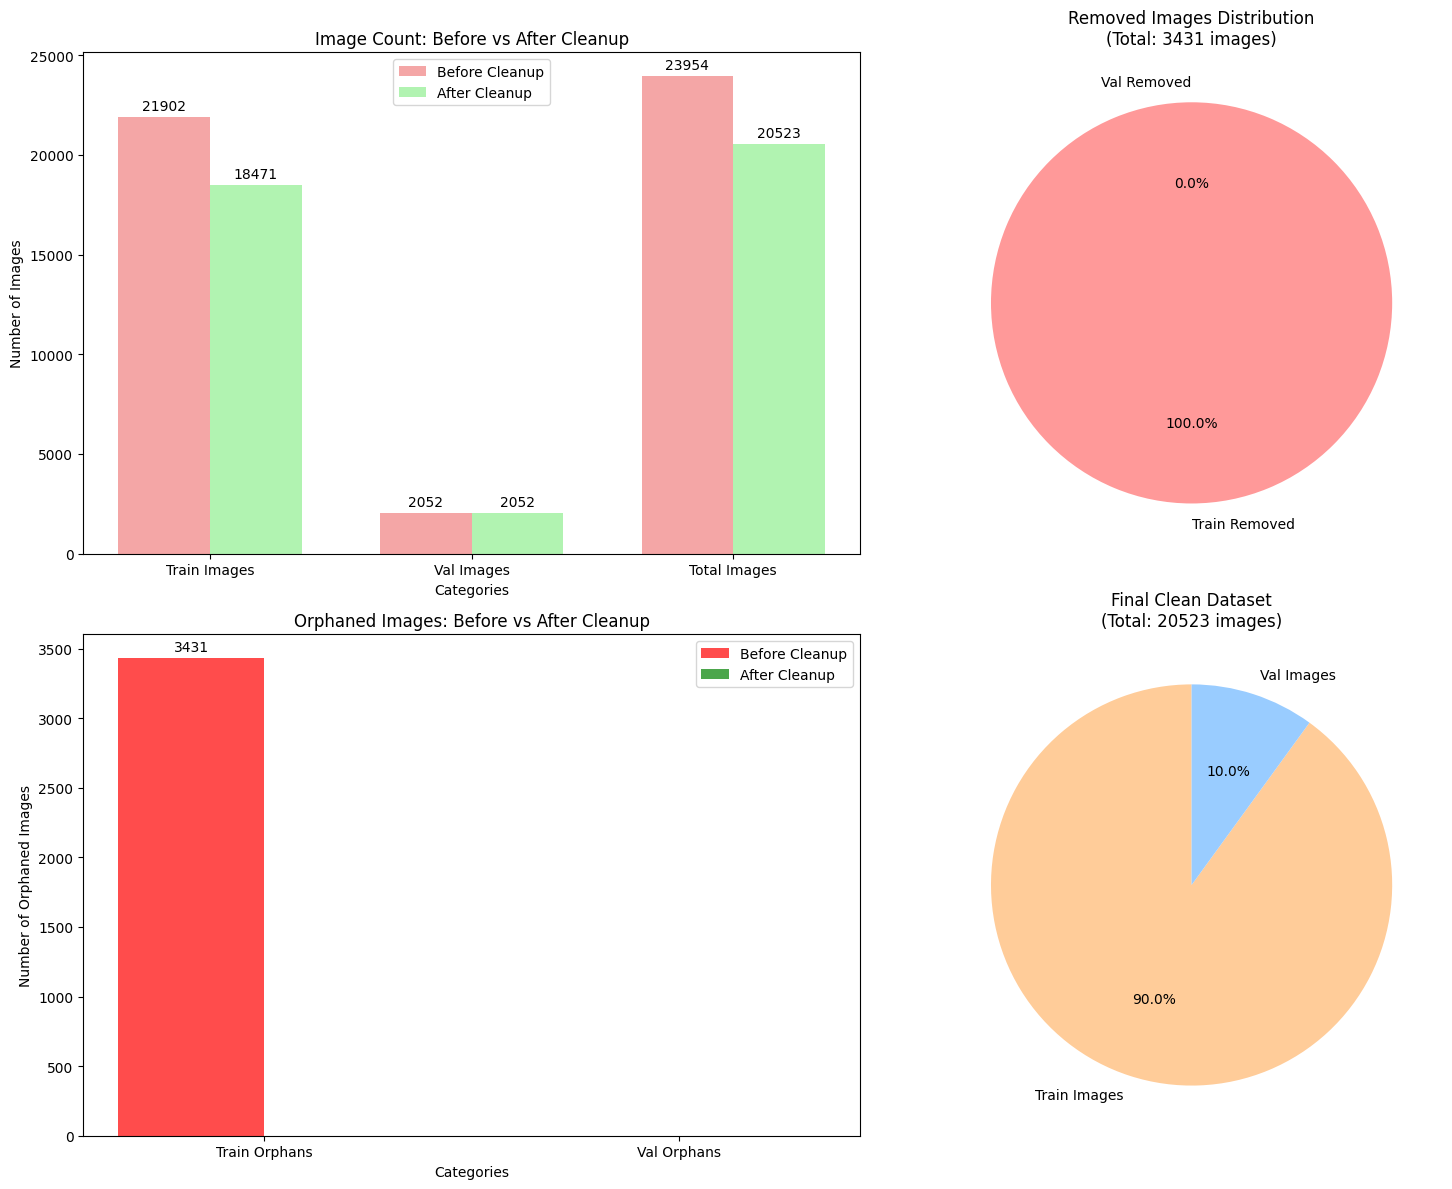


🧹 CLEANUP SUMMARY
📈 Images removed: 3431
📊 Final dataset size: 20523 images
✅ Data quality: 100% (all images have annotations)
📁 Removed images stored in: ./data/removed_images


In [9]:
# Create visualizations for cleanup process
print("📊 Creating cleanup visualization...")

# Create figure with multiple subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Before vs After comparison (Bar chart)
categories = ['Train Images', 'Val Images', 'Total Images']
before_values = [before_cleanup['train_images'], before_cleanup['val_images'], before_cleanup['total_images']]
after_values = [after_cleanup['train_images'], after_cleanup['val_images'], after_cleanup['total_images']]

x = np.arange(len(categories))
width = 0.35

bars1 = ax1.bar(x - width/2, before_values, width, label='Before Cleanup', color='lightcoral', alpha=0.7)
bars2 = ax1.bar(x + width/2, after_values, width, label='After Cleanup', color='lightgreen', alpha=0.7)

ax1.set_xlabel('Categories')
ax1.set_ylabel('Number of Images')
ax1.set_title('Image Count: Before vs After Cleanup')
ax1.set_xticks(x)
ax1.set_xticklabels(categories)
ax1.legend()

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.annotate(f'{int(height)}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

# 2. Removed images breakdown (Pie chart)
if after_cleanup['total_removed'] > 0:
    removed_labels = ['Train Removed', 'Val Removed']
    removed_sizes = [after_cleanup['train_removed'], after_cleanup['val_removed']]
    colors_removed = ['#ff9999', '#66b3ff']
    
    ax2.pie(removed_sizes, labels=removed_labels, colors=colors_removed, autopct='%1.1f%%', startangle=90)
    ax2.set_title(f'Removed Images Distribution\n(Total: {after_cleanup["total_removed"]} images)')
else:
    ax2.text(0.5, 0.5, 'No Images\nRemoved', ha='center', va='center', fontsize=16, 
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.7))
    ax2.set_title('Removed Images Distribution')

# 3. Data quality improvement (before vs after orphaned images)
orphan_categories = ['Train Orphans', 'Val Orphans']
before_orphans = [before_cleanup['train_orphaned'], before_cleanup['val_orphaned']]
after_orphans = [0, 0]  # Should be 0 after cleanup

x_orphan = np.arange(len(orphan_categories))
bars3 = ax3.bar(x_orphan - width/2, before_orphans, width, label='Before Cleanup', color='red', alpha=0.7)
bars4 = ax3.bar(x_orphan + width/2, after_orphans, width, label='After Cleanup', color='green', alpha=0.7)

ax3.set_xlabel('Categories')
ax3.set_ylabel('Number of Orphaned Images')
ax3.set_title('Orphaned Images: Before vs After Cleanup')
ax3.set_xticks(x_orphan)
ax3.set_xticklabels(orphan_categories)
ax3.legend()

# Add value labels
for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax3.annotate(f'{int(height)}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10)

# 4. Final dataset composition
final_labels = ['Train Images', 'Val Images']
final_sizes = [after_cleanup['train_images'], after_cleanup['val_images']]
colors_final = ['#ffcc99', '#99ccff']

ax4.pie(final_sizes, labels=final_labels, colors=colors_final, autopct='%1.1f%%', startangle=90)
ax4.set_title(f'Final Clean Dataset\n(Total: {after_cleanup["total_images"]} images)')

plt.tight_layout()
plt.show()

# Print cleanup summary
print("\n" + "="*80)
print("🧹 CLEANUP SUMMARY")
print("="*80)
print(f"📈 Images removed: {after_cleanup['total_removed']}")
print(f"📊 Final dataset size: {after_cleanup['total_images']} images")
print(f"✅ Data quality: 100% (all images have annotations)")
print(f"📁 Removed images stored in: {removed_images_dir}")
print("="*80)

In [10]:
# Update variables to use cleaned data for subsequent analysis
print("🔄 Updating variables to use cleaned dataset...")

# Update current image sets to the cleaned versions
current_train_images = cleaned_train_images
current_val_images = cleaned_val_images

# Update the all_images set
all_images = current_train_images.union(current_val_images)

# Recalculate data quality metrics with cleaned data
images_without_annotations = set()  # Should be empty now
annotations_without_images = set()  # Check if any annotations lost their images

# Verify all annotations have corresponding images
for annotation in train_annotations_synced + val_annotations_synced:
    img_name = annotation['image']
    if img_name not in all_images:
        annotations_without_images.add(img_name)

print(f"✅ Updated dataset variables:")
print(f"  - Current train images: {len(current_train_images)}")
print(f"  - Current val images: {len(current_val_images)}")
print(f"  - Total images: {len(all_images)}")
print(f"  - Images without annotations: {len(images_without_annotations)}")
print(f"  - Annotations without images: {len(annotations_without_images)}")

if len(annotations_without_images) == 0 and len(images_without_annotations) == 0:
    print(f"🎉 Perfect! Dataset is now 100% clean and aligned!")
else:
    print(f"⚠️ Warning: Some misalignments still exist.")

🔄 Updating variables to use cleaned dataset...
✅ Updated dataset variables:
  - Current train images: 18471
  - Current val images: 2052
  - Total images: 20523
  - Images without annotations: 0
  - Annotations without images: 0
🎉 Perfect! Dataset is now 100% clean and aligned!


## 7. Data Quality Reports
Generate detailed reports on dataset characteristics, answer distributions, and quality metrics.

In [11]:
# Generate comprehensive data quality reports
import pandas as pd
from collections import Counter

print("📊 Generating comprehensive data quality reports...")

# 1. Answer analysis
all_answers = []
answer_lengths = []
unique_answers = set()

for annotation in train_annotations_synced + val_annotations_synced:
    if 'answers' in annotation and annotation['answers']:
        for answer_obj in annotation['answers']:
            answer = answer_obj.get('answer', '').strip().lower()
            if answer:
                all_answers.append(answer)
                answer_lengths.append(len(answer))
                unique_answers.add(answer)

print(f"📝 Answer Statistics:")
print(f"  - Total answers: {len(all_answers)}")
print(f"  - Unique answers: {len(unique_answers)}")
print(f"  - Average answer length: {np.mean(answer_lengths):.1f} characters")
print(f"  - Median answer length: {np.median(answer_lengths):.1f} characters")

# 2. Most common answers
answer_counts = Counter(all_answers)
print(f"\n🔝 Top 10 most common answers:")
for answer, count in answer_counts.most_common(10):
    percentage = (count / len(all_answers)) * 100
    print(f"  - '{answer}': {count} times ({percentage:.1f}%)")

# 3. Question analysis
questions = []
question_lengths = []

for annotation in train_annotations_synced + val_annotations_synced:
    if 'question' in annotation:
        question = annotation['question'].strip()
        if question:
            questions.append(question)
            question_lengths.append(len(question))

print(f"\n❓ Question Statistics:")
print(f"  - Total questions: {len(questions)}")
print(f"  - Average question length: {np.mean(question_lengths):.1f} characters")
print(f"  - Median question length: {np.median(question_lengths):.1f} characters")

# 4. Dataset balance analysis
train_ratio = len(train_annotations_synced) / (len(train_annotations_synced) + len(val_annotations_synced))
val_ratio = 1 - train_ratio

print(f"\n⚖️ Dataset Balance:")
print(f"  - Train set: {len(train_annotations_synced)} samples ({train_ratio*100:.1f}%)")
print(f"  - Validation set: {len(val_annotations_synced)} samples ({val_ratio*100:.1f}%)")
print(f"  - Target ratio: 90/10 split")
print(f"  - Actual ratio: {train_ratio*100:.1f}/{val_ratio*100:.1f} split")

# 5. Create summary DataFrame
summary_data = {
    'Metric': [
        'Total Images', 'Train Images', 'Val Images',
        'Total Annotations', 'Train Annotations', 'Val Annotations',
        'Unique Answers', 'Avg Question Length', 'Avg Answer Length',
        'Data Issues', 'Corrupted Images'
    ],
    'Value': [
        len(all_images), len(current_train_images), len(current_val_images),
        len(train_annotations_synced) + len(val_annotations_synced),
        len(train_annotations_synced), len(val_annotations_synced),
        len(unique_answers), f"{np.mean(question_lengths):.1f} chars",
        f"{np.mean(answer_lengths):.1f} chars", total_issues, len(corrupted_images)
    ]
}

summary_df = pd.DataFrame(summary_data)
print(f"\n📋 Dataset Summary Table:")
print(summary_df.to_string(index=False))

📊 Generating comprehensive data quality reports...
📝 Answer Statistics:
  - Total answers: 205228
  - Unique answers: 41225
  - Average answer length: 11.0 characters
  - Median answer length: 12.0 characters

🔝 Top 10 most common answers:
  - 'unanswerable': 55993 times (27.3%)
  - 'no': 5271 times (2.6%)
  - 'yes': 4559 times (2.2%)
  - 'white': 2490 times (1.2%)
  - 'grey': 2216 times (1.1%)
  - 'black': 2076 times (1.0%)
  - 'blue': 1810 times (0.9%)
  - 'red': 1191 times (0.6%)
  - 'brown': 814 times (0.4%)
  - 'pink': 805 times (0.4%)

❓ Question Statistics:
  - Total questions: 20523
  - Average question length: 32.3 characters
  - Median question length: 25.0 characters

⚖️ Dataset Balance:
  - Train set: 18471 samples (90.0%)
  - Validation set: 2052 samples (10.0%)
  - Target ratio: 90/10 split
  - Actual ratio: 90.0/10.0 split

📋 Dataset Summary Table:
             Metric      Value
       Total Images      20523
       Train Images      18471
         Val Images       2052


## 8. Visualizations and Final Summary
Create visual charts and provide a comprehensive summary of the data splitting and analysis process.

📊 Creating visualizations and final summary...


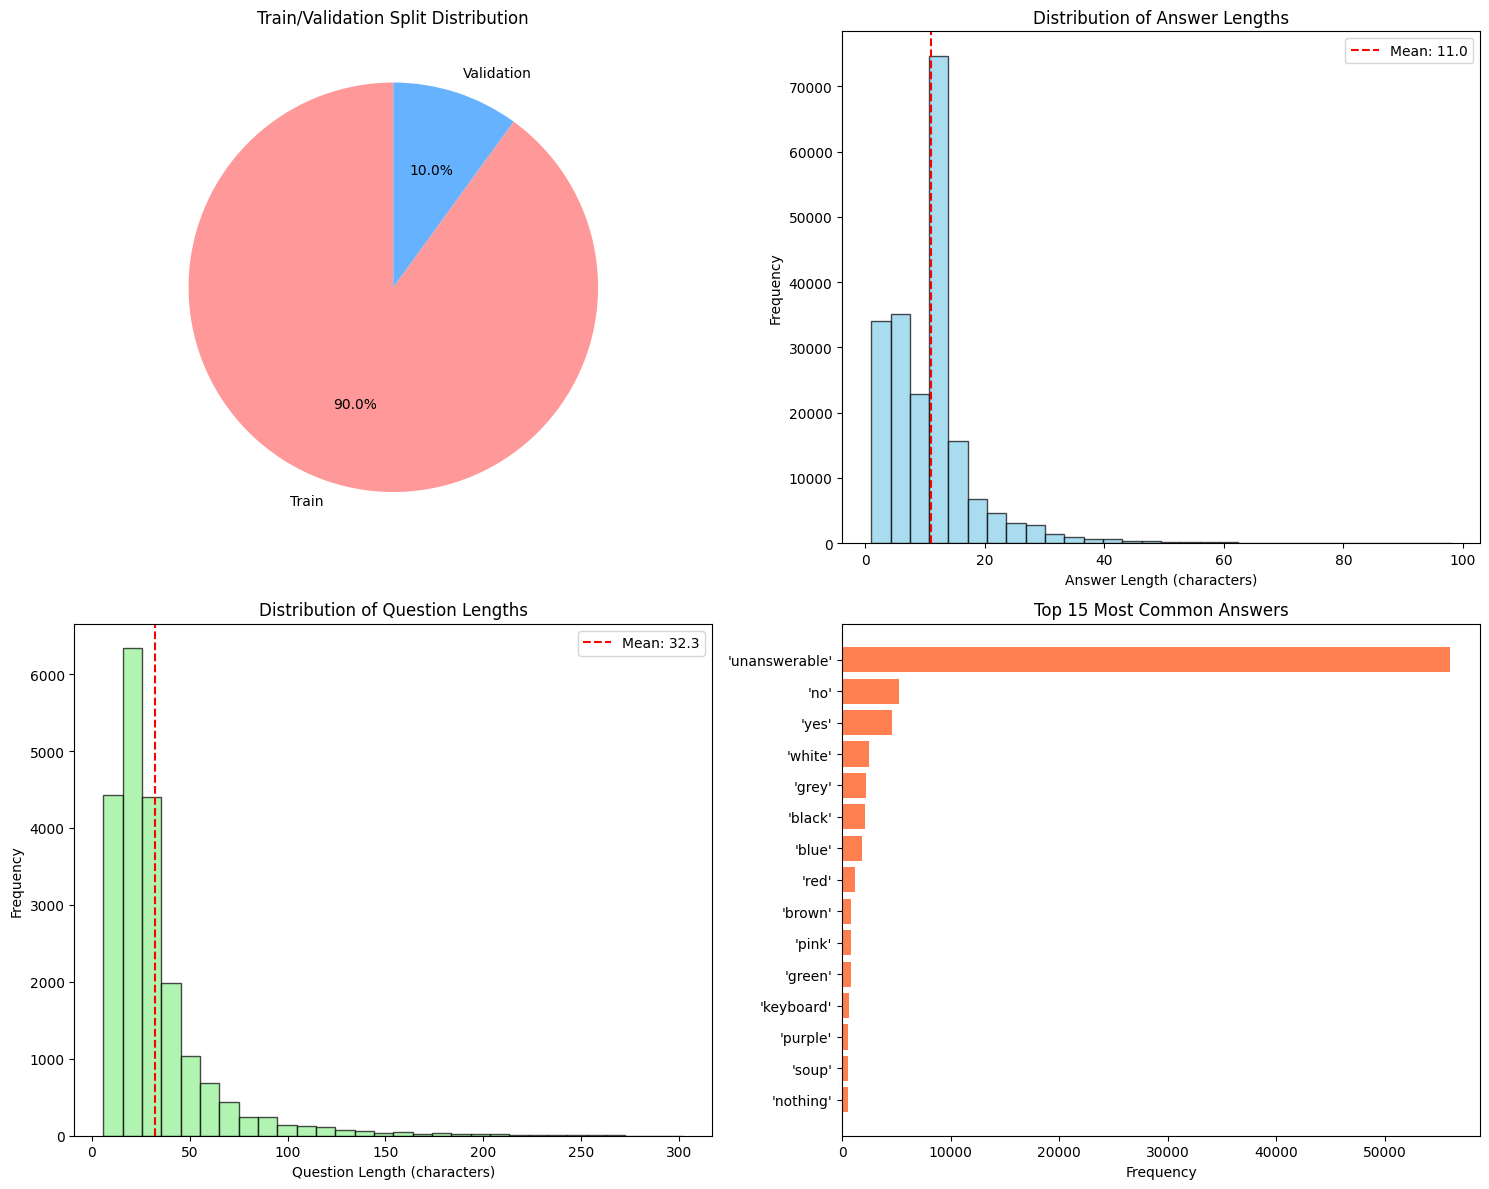


🎯 FINAL DATASET ANALYSIS SUMMARY

📁 Dataset Structure:
  ├── Total Images: 20523
  ├── Train Images: 18471 (90.0%)
  └── Validation Images: 2052 (10.0%)

📝 Annotation Statistics:
  ├── Total Annotations: 20523
  ├── Train Annotations: 18471
  ├── Val Annotations: 2052
  └── Unique Answers: 41225

📊 Quality Metrics:
  ├── Data Issues: 3431
  ├── Corrupted Images: 0
  ├── Missing Annotations: 0
  └── Orphaned Annotations: 0

📏 Content Analysis:
  ├── Avg Question Length: 32.3 characters
  ├── Avg Answer Length: 11.0 characters
  ├── Most Common Answer: 'unanswerable'
  └── Answer Frequency: 55993 times

✅ Split Quality Assessment:
  ├── Target Split: 90/10
  ├── Actual Split: 90.0/10.0
  ├── Deviation: 0.0%
  └── Quality: EXCELLENT

💾 Generated Files:
  ├── ./data/Annotations\train.json (18471 annotations)
  ├── ./data/Annotations\val.json (2052 annotations)
  └── ./data/Annotations\backup\train_original.json (original backup)

🎉 DATA SPLITTING COMPLETE!
The dataset has been successfull

In [12]:
# Create visualizations and final summary
print("📊 Creating visualizations and final summary...")

# 1. Dataset distribution pie chart
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Train/Val split distribution
sizes = [len(train_annotations_synced), len(val_annotations_synced)]
labels = ['Train', 'Validation']
colors = ['#FF9999', '#66B2FF']
ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax1.set_title('Train/Validation Split Distribution')

# Answer length distribution
ax2.hist(answer_lengths, bins=30, color='skyblue', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Answer Length (characters)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Answer Lengths')
ax2.axvline(np.mean(answer_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(answer_lengths):.1f}')
ax2.legend()

# Question length distribution
ax3.hist(question_lengths, bins=30, color='lightgreen', alpha=0.7, edgecolor='black')
ax3.set_xlabel('Question Length (characters)')
ax3.set_ylabel('Frequency')
ax3.set_title('Distribution of Question Lengths')
ax3.axvline(np.mean(question_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(question_lengths):.1f}')
ax3.legend()

# Top answers bar chart
top_answers = answer_counts.most_common(15)
answers, counts = zip(*top_answers)
ax4.barh(range(len(answers)), counts, color='coral')
ax4.set_yticks(range(len(answers)))
ax4.set_yticklabels([f"'{ans[:20]}...'" if len(ans) > 20 else f"'{ans}'" for ans in answers])
ax4.set_xlabel('Frequency')
ax4.set_title('Top 15 Most Common Answers')
ax4.invert_yaxis()

plt.tight_layout()
plt.show()

# 2. Final comprehensive summary
print("\n" + "="*80)
print("🎯 FINAL DATASET ANALYSIS SUMMARY")
print("="*80)

print(f"\n📁 Dataset Structure:")
print(f"  ├── Total Images: {len(all_images)}")
print(f"  ├── Train Images: {len(current_train_images)} ({len(current_train_images)/len(all_images)*100:.1f}%)")
print(f"  └── Validation Images: {len(current_val_images)} ({len(current_val_images)/len(all_images)*100:.1f}%)")

print(f"\n📝 Annotation Statistics:")
print(f"  ├── Total Annotations: {len(train_annotations_synced) + len(val_annotations_synced)}")
print(f"  ├── Train Annotations: {len(train_annotations_synced)}")
print(f"  ├── Val Annotations: {len(val_annotations_synced)}")
print(f"  └── Unique Answers: {len(unique_answers)}")

print(f"\n📊 Quality Metrics:")
print(f"  ├── Data Issues: {total_issues}")
print(f"  ├── Corrupted Images: {len(corrupted_images)}")
print(f"  ├── Missing Annotations: {len(images_without_annotations)}")
print(f"  └── Orphaned Annotations: {len(annotations_without_images)}")

print(f"\n📏 Content Analysis:")
print(f"  ├── Avg Question Length: {np.mean(question_lengths):.1f} characters")
print(f"  ├── Avg Answer Length: {np.mean(answer_lengths):.1f} characters")
print(f"  ├── Most Common Answer: '{answer_counts.most_common(1)[0][0]}'")
print(f"  └── Answer Frequency: {answer_counts.most_common(1)[0][1]} times")

print(f"\n✅ Split Quality Assessment:")
split_deviation = abs(train_ratio - 0.9)
if split_deviation < 0.05:
    quality = "EXCELLENT"
elif split_deviation < 0.1:
    quality = "GOOD"
else:
    quality = "NEEDS ADJUSTMENT"

print(f"  ├── Target Split: 90/10")
print(f"  ├── Actual Split: {train_ratio*100:.1f}/{val_ratio*100:.1f}")
print(f"  ├── Deviation: {split_deviation*100:.1f}%")
print(f"  └── Quality: {quality}")

print(f"\n💾 Generated Files:")
print(f"  ├── {train_json_path} ({len(train_annotations_synced)} annotations)")
print(f"  ├── {val_json_path} ({len(val_annotations_synced)} annotations)")
print(f"  └── {backup_train_path} (original backup)")

print(f"\n🎉 DATA SPLITTING COMPLETE!")
print(f"The dataset has been successfully split and is ready for VQA training.")
print("="*80)